In [2]:
#Import block: 
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import pandas as pd

from iminuit import Minuit, cost

from scipy import stats, interpolate
from scipy.stats import trapezoid, chi2
from scipy.interpolate import interp1d, CubicSpline
from scipy.integrate import quad

## Problem 4: Exam in Advanced Methods in Applied Statistics
Author: Aske Roelshøj

KU-ID: KVF851

Date(s): Thurs. March 26 to Fri. March 27, 2026

In [3]:
#Minimizer: 
def minimizer(x, func, params, limits = None, fixed_params = None):

    # Dynamically accept any number of parameters
    def log_likelihood(*params):
        return -np.sum(np.log(func(x, *params)))
    
    m = Minuit(log_likelihood, *params)
    if limits is not None:
        for i, (low, high) in enumerate(limits):
            m.limits[i] = (low, high)
    if fixed_params is not None:
        for i, val in fixed_params.items():
            m.fixed[i] = True
            m.values[i] = val
    m.migrad()  # Minimize
    
    print(f"Estimated parameters: {m.values}")
    print(f"Parameter errors: {m.errors}")
    
    min_log_likelihood = m.fval
    print(f"Minimum log-likelihood: {min_log_likelihood}")
    
    return m.values, m.errors, min_log_likelihood

## 4a

In [ ]:
data = np.loadtxt('Data/GlacierElevation.txt', skiprows=1)
print(len(data))
data

1000


array([5040., 4120., 5120., 5000., 2480., 2740., 2800., 2600., 2648.,
       3000., 3080., 2960., 2740., 2900., 3180., 2820., 2720., 2760.,
       2800., 3120., 2580., 2830., 3160., 4980., 4650., 5740., 5760.,
       6100., 5220., 5250., 5720., 5240., 5680., 5300., 5460., 5350.,
       4710., 5160., 4498., 5800., 4340., 5700., 5310., 4612., 5160.,
       5480., 5480., 4920., 5790., 4910., 4320., 6070., 4530., 5440.,
       6030., 5670., 5548., 5405., 5740., 5793., 5910., 6219., 5950.,
       5100., 5000., 5520., 5240., 5840., 5495., 5750., 5820., 5800.,
       5080., 5000., 5190., 4932., 5330., 5300., 5300., 5360., 5660.,
       5650., 5615., 5680., 5530., 5540., 5580., 5840., 5770., 5908.,
       5450., 5710., 5540., 5516., 5480., 4995., 5614., 5310., 5820.,
       5640., 5800., 5600., 5718., 5710., 5560., 5480., 5800., 5740.,
       5620., 5620., 5560., 5760., 5500., 5720., 5630., 5640., 5580.,
       5540., 5550., 5995., 5880., 6057., 5830., 5880., 5860., 5730.,
       5660., 5660.,

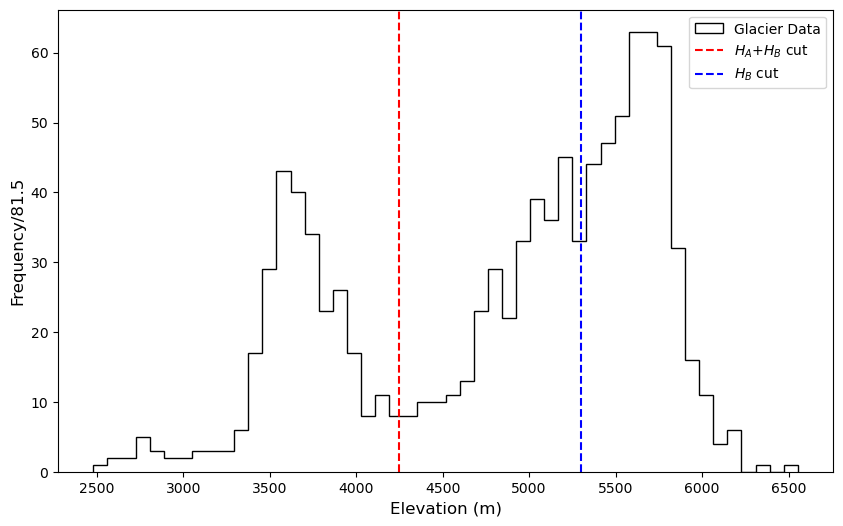

In [5]:
#Start by plotting the data: 
fig, ax = plt.subplots(figsize = (10, 6))
ax.hist(data, bins = 50, color = 'k', histtype='step', label='Glacier Data')
ax.set_xlabel('Elevation (m)', fontsize = 12)
ax.axvline(4250, color = 'r', linestyle = '--', label = '$H_A$+$H_B$ cut')
ax.axvline(5300, color = 'b', linestyle = '--', label = '$H_B$ cut')
ax.set_ylabel(f'Frequency/{((np.max(data)-np.min(data))/50):.1f}', fontsize = 12)
ax.legend();

In [6]:
def gauss(x, mu, sigma):
    return stats.norm.pdf(x, mu, sigma)

def double_gauss(x, mu1, sigma1, mu2, sigma2, A):
    return A * gauss(x, mu1, sigma1) + (1 - A) * gauss(x, mu2, sigma2)

def triple_gauss(x, mu1, sigma1, mu2, sigma2, mu3, sigma3, A1, A2):
    return A1 * gauss(x, mu1, sigma1) + A2 * gauss(x, mu2, sigma2) + (1 - A1 - A2) * gauss(x, mu3, sigma3)

x_vals = np.linspace(np.min(data), np.max(data), 1000)

In [7]:
cut_A = 4250
#Split the data into two parts:
data_A1 = data[data < cut_A]
A1_share = len(data_A1)/len(data)
data_A2= data[data >= cut_A]

#Fit the Gaussian to the data:
params_A, errors_A, min_log_likelihood_A = minimizer(data, double_gauss, [np.mean(data_A1), np.std(data_A1), np.mean(data_A2), np.std(data_A2), A1_share])

Estimated parameters: <ValueView x0=3717.0192277460123 x1=378.3950106739147 x2=5376.3782115270515 x3=393.07800070079276 x4=0.3114551734090427>
Parameter errors: <ErrorView x0=40.88337637950575 x1=33.109599059429954 x2=24.887284897341065 x3=19.37424170296691 x4=0.02322016673407145>
Minimum log-likelihood: 7956.925569121391


In [8]:
cut_B1 = 4250
cut_B2 = 5300

#Split the data into three parts:
data_B1 = data[data < cut_B1]
B1_share = len(data_B1)/len(data)
data_B2 = data[(data >= cut_B1) & (data < cut_B2)]
B2_share = len(data_B2)/len(data)
data_B3 = data[data >= cut_B2]

#Fit the Gaussian to the data:
params_B, errors_B, min_log_likelihood_B = minimizer(data, triple_gauss, [np.mean(data_B1), np.std(data_B1), np.mean(data_B2), np.std(data_B2), np.mean(data_B3), np.std(data_B3), B1_share, B2_share])

Estimated parameters: <ValueView x0=3683.3378366741285 x1=350.4411311492463 x2=5233.599297372139 x3=413.35784517341074 x4=5688.7827137763115 x5=134.47570252812883 x6=0.2972710287371154 x7=0.5120309422496943>
Parameter errors: <ErrorView x0=35.77046748945407 x1=27.790637476863125 x2=48.90673950912419 x3=24.929883041520462 x4=25.137866337286194 x5=29.27840019508331 x6=0.02237644585896002 x7=0.04797862907340131>
Minimum log-likelihood: 7921.359616963136


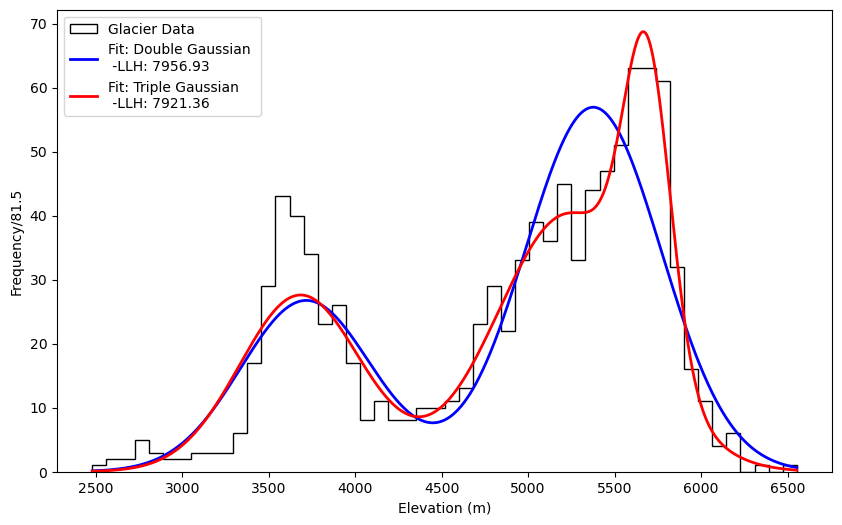

In [9]:
#Start by plotting the data: 
fig, ax = plt.subplots(figsize=(10, 6))
num_bins = 50
counts, bins, _ = ax.hist(data, bins=num_bins, label=f'Glacier Data', histtype='step', color = 'k')
bin_width = (np.max(data)-np.min(data))/num_bins
y_A = double_gauss(x_vals, *params_A) * len(data) * bin_width
y_B = triple_gauss(x_vals, *params_B) * len(data) * bin_width
ax.plot(x_vals, y_A, color='b', linewidth = 2,  label=f'Fit: Double Gaussian \n -LLH: {min_log_likelihood_A:.2f}')
ax.plot(x_vals, y_B, color='r', linewidth = 2, label=f'Fit: Triple Gaussian \n -LLH: {min_log_likelihood_B:.2f}')
ax.set_xlabel('Elevation (m)')
ax.set_ylabel(f'Frequency/{bin_width:.1f}')
ax.legend();

## 4b

In [10]:
def llh_ratio(llh_null, llh_alt):
    delta =  -2 * (llh_null - llh_alt)
    print('Delta is: ', delta)
    return delta

delta_llh = llh_ratio(min_log_likelihood_B, min_log_likelihood_A)

def p_value(delta, df):
    p_val = 1 - chi2.cdf(delta, df)
    print('p-value is: ', p_val)
    return p_val

p_val = p_value(delta_llh, 3)

Delta is:  71.13190431650946
p-value is:  2.4424906541753444e-15


In [11]:
#sigmas away:
stats.norm.ppf(1 - p_val/2)

np.float64(7.916520712471189)

# Workshop: 

Estimated parameters: <ValueView x0=3650.597902097902 x1=316.83674050756633>
Parameter errors: <ErrorView x0=26.495241865574265 x1=18.734929102712595>
Minimum log-likelihood: 2052.714995830038
Estimated parameters: <ValueView x0=5343.929971988796 x1=422.0719144629628>
Parameter errors: <ErrorView x0=22.33843433950839 x1=15.795626777149355>
Minimum log-likelihood: 5329.377571744895


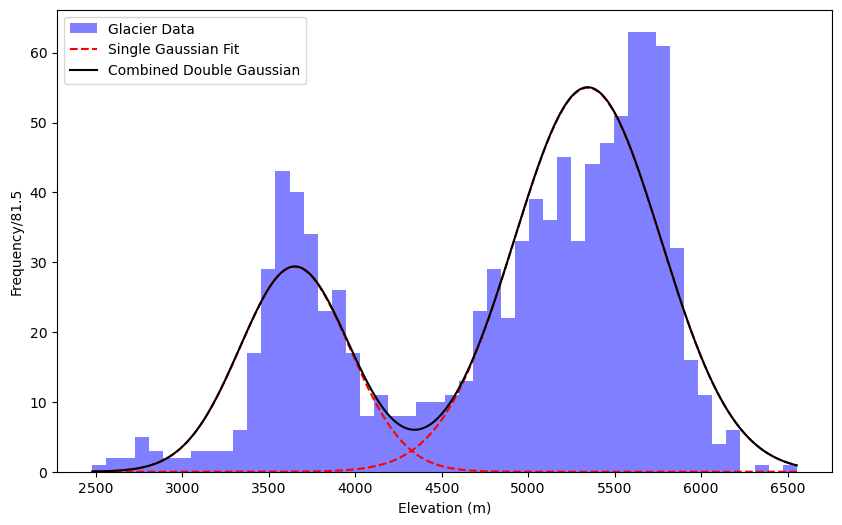

In [12]:
#Instead fit single gaussians to each peak, and then combine: 

params_A1, errors_A1, min_log_likelihood_A1 = minimizer(data_A1, gauss, [np.mean(data_A1), np.std(data_A1)])
params_A2, errors_A2, min_log_likelihood_A2 = minimizer(data_A2, gauss, [np.mean(data_A2), np.std(data_A2)])

y_A1 = gauss(x_vals, *params_A1) * len(data_A1) * bin_width
y_A2 = gauss(x_vals, *params_A2) * len(data_A2) * bin_width  

#Combining: 
y_combined = y_A1 + y_A2
y_combined /= np.trapezoid(y_combined, x_vals)  # Normalize to ensure the area under the curve is 1
y_combined *= len(data) * bin_width  # Scale to match the histogram

#Plotting the single gaussians: 
fig, ax = plt.subplots(figsize=(10, 6))
num_bins = 50
counts, bins, _ = ax.hist(data, bins=num_bins, label=f'Glacier Data', alpha = 0.5, color = 'b')
bin_width = (np.max(data)-np.min(data))/num_bins
ax.plot(x_vals, y_A1, '--', color='r', label=f'Single Gaussian Fit') 
ax.plot(x_vals, y_A2, '--', color='r')
ax.plot(x_vals, y_combined, color='k', label=f'Combined Double Gaussian')
ax.set_xlabel('Elevation (m)')
ax.set_ylabel(f'Frequency/{bin_width:.1f}')
ax.legend();

## 4b